In [1]:
import importlib
import numpy as np
import os
import polars as pl
import scipy.sparse as sp
import sys
import torch
import torch.nn as nn
from tqdm import tqdm

from datasets import DATA_FOLDER, Dataloader, prepare_interaction_data
from util import CHECKPOINT_FOLDER, get_checkpoint_filepath, load_checkpoint, load_config_from_checkpoint

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.mps.is_available() else torch.device("cpu")

DATASET = "MSD"
#checkpoint = "TopKSAE-8192-26b50839.ckpt" #elsa+l2
#checkpoint = "TopKSAE-8192-d7b1a8cb.ckpt" #elsa+cosine
checkpoint = "TopKSAE-8192-369a6053.ckpt" #multvae+l2

SAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/{checkpoint}"


sae_cfg = load_config_from_checkpoint(SAE_CHECKPOINT_PATH)
cf_model_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{sae_cfg['pretrained_model_checkpoint']}"
cf_model_cfg = load_config_from_checkpoint(cf_model_checkpoint_path)

interactions_df, train_csr, val_csr, test_csr, train_users, val_users, test_users, items = prepare_interaction_data(cf_model_cfg)
train_users_to_idxs = {uid: uidx for uidx, uid in enumerate(train_users)}
val_users_to_idxs = {uid: uidx for uidx, uid in enumerate(val_users)}
test_users_to_idxs = {uid: uidx for uidx, uid in enumerate(test_users)}
items_to_idxs = {iid: iidx for iidx, iid in enumerate(items)}

Removing items with < 200 interactions...
Removing users with < 20 interactions...
Dataset info: users=571355, items=41140, interactions=33633450
Train split info: users=457084, items=41140, interactions=26909047
Val split info: users=57136, items=41140, interactions=3357963
Test split info: users=57135, items=41140, interactions=3366440


In [3]:


items_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/song_names.csv").rename({"song_id": "item_id"}).cast({"item_id": pl.String}).cast({"item_id": pl.Categorical}).collect()
)


cf_model_class = getattr(importlib.import_module(cf_model_cfg["model_module"]), cf_model_cfg["model_class"])
if cf_model_cfg["model_class"] == "ELSA":
    cf_model = cf_model_class(train_csr.shape[1], cf_model_cfg["embedding_dim"]).to(device)
elif cf_model_cfg["model_class"] == "MultVAE":
    cf_model = cf_model_class(
        train_csr.shape[1],
        [int(x) for x in cf_model_cfg["hidden_dims"].split(",") if x.strip()],
        cf_model_cfg["embedding_dim"],
        cf_model_cfg["annealing_beta"],
        cf_model_cfg["annealing_steps"],
    ).to(device)

_, _ = load_checkpoint(cf_model, None, get_checkpoint_filepath(cf_model_cfg), device, None)

sae_model_class = getattr(importlib.import_module(sae_cfg["model_module"]), sae_cfg["model_class"])
sae_extra_params = {k: sae_cfg[k] for k in sae_cfg.keys() if k in ["l1_coef", "k"]}
sae = sae_model_class(cf_model_cfg["embedding_dim"], sae_cfg["embedding_dim"], sae_cfg["reconstruction_loss"], l1_coef=sae_cfg["l1_coef"], k=sae_cfg["k"]).to(
    device
)
_, _ = load_checkpoint(sae, None, get_checkpoint_filepath(sae_cfg), device, None)

Loaded checkpoint from checkpoints/MSD/MultVAE-1024-da1abc6f.ckpt (after 25 epochs)
Loaded checkpoint from checkpoints/MSD/TopKSAE-8192-369a6053.ckpt (after 999 epochs)


In [4]:
sparse_embeddings = []
onehot_items_dataloader = Dataloader(sp.eye(len(items), dtype=np.float32, format="csr"), batch_size=1024, device=device)
with torch.no_grad():
    for onehot_batch in tqdm(onehot_items_dataloader):
        cf_model_embedding = cf_model.encode(onehot_batch)  # Tensor, shape = (batch.shape[0] x elsa_cfg["embedding_dim"])
        if cf_model_cfg["model_class"] != "ELSA":
            cf_model_embedding = cf_model_embedding[0]

        sae_embedding, _, input_mean, input_std = sae.encode(cf_model_embedding)
        sparse_embeddings.append(sp.csr_matrix(sae_embedding.cpu().numpy()))
sparse_embeddings = sp.vstack(sparse_embeddings)

neuron_is_alive = np.asarray(sparse_embeddings.sum(axis=0)).flatten() != 0
living_neurons = np.where(neuron_is_alive)[0]
dead_neuron_count = sparse_embeddings.shape[1] - neuron_is_alive.sum()
print(f"{dead_neuron_count} dead neurons out of {sparse_embeddings.shape[1]} ({dead_neuron_count / sparse_embeddings.shape[1]:.2%})")
print(f"{neuron_is_alive.sum()} alive ones")

100%|██████████████████████████████████████████████████████████████████████████████████| 41/41 [00:54<00:00,  1.34s/it]

5806 dead neurons out of 8192 (70.87%)
2386 alive ones


In [5]:
DATASET = "MSD"
tag_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/song_tag_assignment.csv")
    .rename({"song_id": "item_id"})
    .cast({"tag": pl.String, "item_id": pl.String})
    .cast({"tag": pl.Categorical, "item_id": pl.Categorical})
    .filter(pl.col("tag").count().over("tag") >= 100)  # keep only tags assigned at least 100 times
    .filter(pl.col("item_id").is_in(items))  # keep only items with interactions
    .with_columns(pl.col("item_id").replace_strict(items_to_idxs).alias("item_idx"))
    .collect()
)

tag_df

C:\Users\lpesk\AppData\Local\Temp\ipykernel_14632\1437156084.py:3: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance
  pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/song_tag_assignment.csv")


item_id,tag,weight,item_idx
cat,cat,f64,i64
"""SONCXZL12A8C13F6B9""","""classic rock""",1.0,11262
"""SOZMEWR12A6701EBD9""","""classic rock""",1.0,11631
"""SOBUOEK12A6D4F9908""","""classic rock""",1.0,4906
"""SONYAFR12AB017F05A""","""classic rock""",1.0,13598
"""SOQJHUW12AB0188A24""","""classic rock""",1.0,7979
…,…,…,…
"""SOCVHZE12AB01825AB""","""outskirts of expansion""",33.0,21814
"""SOBEMUS12AB0183B42""","""outskirts of expansion""",50.0,21865
"""SOHKXSO12AB0189B61""","""outskirts of expansion""",100.0,26649


In [6]:
#tags = tag_df["tag"].unique(maintain_order=True).to_numpy()


tags = tag_df["tag"].cat.get_categories().to_numpy()
n_tags = len(tags)
n_items = len(items) 
# 3) Build sparse tag–item matrix: shape (n_tags, n_items)
row_idx = tag_df["tag"].to_physical().to_numpy()

col_idx = tag_df["item_idx"].to_numpy()
data    = tag_df["weight"].cast(pl.Float32).to_numpy()

tag_item_counts = sp.csr_matrix(
    (data, (row_idx, col_idx)),
    shape=(n_tags, n_items),
)

tag_item_counts

<1761x41140 sparse matrix of type '<class 'numpy.float32'>'
	with 692080 stored elements in Compressed Sparse Row format>

In [7]:
pl.Series(tag_item_counts.data).describe()

statistic,value
str,f64
"""count""",692080.0
"""null_count""",0.0
"""mean""",19.507685
"""std""",27.564539
"""min""",1.0
"""25%""",3.0
"""50%""",7.0
"""75%""",22.0
"""max""",300.0


In [8]:
def compute_tfidf(X):
    """
    Compute TF-IDF for a term-document value matrix.
    Parameters:
    X: np.ndarray (num_terms, num_documents)
    Returns:
    tfidf_matrix: np.ndarray (num_terms, num_documents) - TF-IDF values
    """
    # Compute Term Frequency (TF) - Normalize by column sum
    tf = X / np.sum(X, axis=0, keepdims=True)
    tf[np.isnan(tf)] = 0  # Handle division by zero
    # Compute Document Frequency (DF) - Count nonzero occurrences of each term
    df = np.count_nonzero(X, axis=1)
    # Compute Inverse Document Frequency (IDF) - Log-scaled
    num_documents = X.shape[1]
    idf = np.log((num_documents + 1) / (df + 1)) + 1  # Smoothing
    # Compute TF-IDF
    tfidf_matrix = tf * idf[:, np.newaxis]
    return tfidf_matrix


pti = tag_item_counts.copy()
pti.data /= pti.data.sum()
tag_neuron_activity = pti @ sparse_embeddings

# top_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=0)]  # term = tag, document = neuron
top_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=1)]  # term = neuron, document = tag
top_tag_per_neuron[~neuron_is_alive] = None

# top_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=0)  # term = neuron, document = tag
top_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=1)  # term = tag, document = neuron

print(pl.Series("top_neuron", top_neuron_per_tag).value_counts(sort=True))
print(pl.Series("top_tag", top_tag_per_neuron[neuron_is_alive]).value_counts(sort=True))

C:\Users\lpesk\AppData\Local\Temp\ipykernel_14632\2475554274.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


shape: (937, 2)
┌────────────┬───────┐
│ top_neuron ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 4887       ┆ 11    │
│ 4921       ┆ 8     │
│ 2708       ┆ 8     │
│ 7537       ┆ 8     │
│ 4449       ┆ 8     │
│ …          ┆ …     │
│ 7288       ┆ 1     │
│ 1201       ┆ 1     │
│ 880        ┆ 1     │
│ 2315       ┆ 1     │
│ 7938       ┆ 1     │
└────────────┴───────┘
shape: (1_098, 2)
┌───────────────┬───────┐
│ top_tag       ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ classic rock  ┆ 21    │
│ radiohead     ┆ 12    │
│ post-grunge   ┆ 10    │
│ seattle       ┆ 9     │
│ skate punk    ┆ 9     │
│ …             ┆ …     │
│ spring        ┆ 1     │
│ meditative    ┆ 1     │
│ Sarah Records ┆ 1     │
│ body parts    ┆ 1     │
│ joyful        ┆ 1     │
└───────────────┴───────┘


In [9]:
pl.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort(by="top neuron").tail(10)

tag,top neuron
str,i64
"""Glam Metal""",8107
"""sleaze rock""",8107
"""south""",8153
"""melodic hard rock""",8153
"""gittis""",8162
"""feelings""",8162
"""jo""",8162
"""garage""",8167
"""body parts""",8167


In [10]:
import pandas as pd

df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df.tag.str.contains("han")]

,tag,top neuron
1341,patchanka,92
1523,Rihanna,484
431,chanson francaise,532
1530,shorter than 2 minutes,1313
530,handclaps,1356
433,chanson,1512
1668,Bhangra,2404
1002,hand claps,2588
1411,hands up,3550
712,redder than red,4600


In [34]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df["top neuron"] == 4776]

,tag,top neuron
1654,Chanson Française,4776
1509,yolala indie fav,4776


In [35]:
top_tag_per_neuron[4600]

'redder than red'

In [13]:
import pandas as pd

df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.iloc[400:450]

,tag,top neuron
1201,singalong,1857
761,arabic,1870
1738,sufi,1870
1581,Arguman-loved tracks,1876
720,album rock,1877
1352,Rock Roll,1877
1456,Dark metal,1880
1536,drum'n'bass,1884
69,electronic,1884
1121,dansk,1897


In [14]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df.tag.str.contains("rock")]

,tag,top neuron
837,rockin,92
190,pop rock,353
1622,country-rock,360
518,italian rock,540
839,christian rock,723
...,...,...
793,electro rock,8027
1604,classic hard rock,8029
1475,sonic rock,8032
1052,sleaze rock,8107


In [36]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df["top neuron"] == 8107]

,tag,top neuron
1052,sleaze rock,8107
1051,Glam Metal,8107


In [16]:
tag_df.filter(pl.col("tag") == "british")["item_id"].unique()

item_id
cat
"""SOBUOEK12A6D4F9908"""
"""SOCESFW12A58A7DC8C"""
"""SOLLQFW12A8151BD44"""
"""SOGIWOH12A6D4F9646"""
"""SOBSICO12A67020895"""
…
"""SOVDROH12A8C131B54"""
"""SONZZWM12A6310D85D"""
"""SODNLPU12A8C1312B8"""


In [17]:
list(tag_df.filter(pl.col("item_id") == "SOBUOEK12A6D4F9908")["tag"].unique())

['classic rock',
 'pop',
 'cool',
 'beautiful',
 'indie',
 'classic',
 '80s',
 'dance',
 'rock',
 'alternative',
 'indie rock',
 'favorites',
 'Favourites',
 'Soundtracks',
 'loved',
 'melancholy',
 'Awesome',
 'punk',
 'british',
 'Bittersweet',
 'nostalgia',
 'Love',
 '1980s',
 'britpop',
 'male vocalists',
 'Favorite',
 'Mellow',
 'night',
 'dark',
 'melancholic',
 'perfect',
 'romantic',
 'sexy',
 'favourite',
 'new wave',
 'UK',
 'alternative rock',
 'live',
 '77davez-all-tracks',
 'oldies',
 'Soundtrack',
 'Favourite Songs',
 'amazing',
 'post-punk',
 'atmospheric',
 'darkwave',
 'dark wave',
 'memories',
 'Love it',
 'Gothic Rock',
 'fav',
 'Gothic',
 'goth',
 'intense',
 'favorite songs',
 'Dreamy',
 'best songs ever',
 "80's",
 'chaser i',
 'Post punk',
 'genius',
 '1984',
 'dramatic',
 'Retro',
 'haunting',
 'halloween',
 'england',
 'songs that i will still be listening to in a billion years']

In [18]:
normalized_tag_neuron_activity = compute_tfidf(tag_neuron_activity.toarray().T)  # term = neuron, document = tag
normalized_tag_neuron_activity.shape

C:\Users\lpesk\AppData\Local\Temp\ipykernel_14632\2475554274.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


(8192, 1761)

In [19]:
mean_neuron_activity = normalized_tag_neuron_activity.sum(axis=0)
mean_neuron_activity.shape

(1761,)

In [20]:
epsilon = 1e-9
import pandas as pd
from scipy.stats import entropy

neuron_entropy = []
neuron_kl_div = []
neuron_top_tags = []
neuron_top_movies = []
valid_neurons = []

for n in range(normalized_tag_neuron_activity.shape[0]):
    neron_tag_activation = normalized_tag_neuron_activity[n, :]
    if neron_tag_activation.sum() > 0:  # living neuron
        n_entropy = entropy(neron_tag_activation)

        neron_tag_activation = neron_tag_activation.copy() + epsilon
        n_kl_div = entropy(mean_neuron_activity, neron_tag_activation)
        # n_kl_div = entropy(neron_tag_activation,mean_neuron_activity)

        valid_neurons.append(n)
        neuron_entropy.append(n_entropy)
        neuron_kl_div.append(n_kl_div)


res = pd.DataFrame({"id": valid_neurons, "entropy": neuron_entropy, "KL_div": neuron_kl_div})
res

,id,entropy,KL_div
0,2,5.254901,7.955111
1,5,6.225545,5.469701
2,7,2.604769,10.391266
3,8,3.842881,10.840272
4,10,4.062981,10.679401
...,...,...,...
2360,8176,4.922576,9.585667
2361,8180,3.764367,9.547407
2362,8182,4.011576,11.496621
2363,8185,3.980432,10.530002


In [21]:
res["norm_entropy_diff"] = (entropy(mean_neuron_activity) - res.entropy) / entropy(mean_neuron_activity)

In [22]:
chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
res.to_csv(f"results/res_neuron_tag_{chckpt_name}.csv")

In [23]:
entropy(mean_neuron_activity)

7.468226053555772

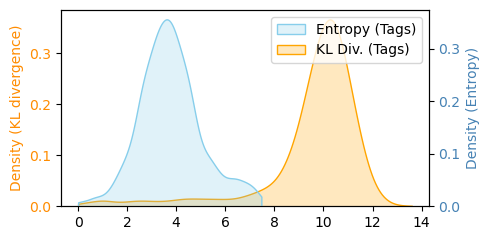

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

min_entropy = res["entropy"].min()
max_entropy = res["entropy"].max()

min_kldiv = res["KL_div"].min()
max_kldiv = res["KL_div"].max()

# Initialize the plot
fig, ax2 = plt.subplots(figsize=(5, 2.5))

sns.kdeplot(res["KL_div"], ax=ax2, label="KL Div. (Tags)", fill=True, color="orange", linestyle="-", clip=(min_kldiv, max_kldiv))

ax2.set_ylabel("Density (KL divergence)", color="#FF8C00")
ax2.tick_params(axis="y", labelcolor="#FF8C00")

# Create a second y-axis for KL_div
ax1 = ax2.twinx()


# Plot the KDE for entropy on the first y-axis
sns.kdeplot(res["entropy"], ax=ax1, label="Entropy (Tags)", fill=True, color="skyblue", linestyle="-", clip=(min_entropy, max_entropy))

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Entropy)", color="#4682B4")
ax1.tick_params(axis="y", labelcolor="#4682B4")


# Add a title and legend
# plt.title("KDE of Entropy and KL Divergence with Dual Axes")
handles, labels = ax1.get_legend_handles_labels()  # Get handles and labels from ax1
handles2, labels2 = ax2.get_legend_handles_labels()  # Get handles and labels from ax2

# Combine the handles and labels from both axes
handles.extend(handles2)
labels.extend(labels2)

# Show the legend
plt.legend(handles=handles, labels=labels, loc="upper right")
fig.tight_layout()

# ax1.set_xlim(-0.5, 24)
plt.savefig("rq2_neuron_tag_tfidf.pdf")

In [25]:
normalized_tag_neuron_activity = compute_tfidf(tag_neuron_activity.toarray()).T  # term = tag, document = neuron
normalized_tag_neuron_activity.shape

C:\Users\lpesk\AppData\Local\Temp\ipykernel_14632\2475554274.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


(8192, 1761)

In [26]:
mean_tag_activity = normalized_tag_neuron_activity.sum(axis=1)
mean_tag_activity.shape

(8192,)

In [27]:
import pandas as pd
from scipy.stats import entropy

neuron_entropy = []
neuron_kl_div = []
neuron_top_tags = []
neuron_top_movies = []
valid_tags = []

for t in range(normalized_tag_neuron_activity.shape[1]):
    neron_tag_activation = normalized_tag_neuron_activity[:, t]
    if neron_tag_activation.sum() > 0:  # living neuron
        n_entropy = entropy(neron_tag_activation)

        neron_tag_activation = neron_tag_activation.copy() + epsilon
        n_kl_div = entropy(mean_tag_activity, neron_tag_activation)
        # n_kl_div = entropy(neron_tag_activation,mean_tag_activity)

        valid_tags.append(t)
        neuron_entropy.append(n_entropy)
        neuron_kl_div.append(n_kl_div)


res = pd.DataFrame({"id": valid_tags, "tag": tags[valid_tags], "entropy": neuron_entropy, "KL_div": neuron_kl_div})
res

,id,tag,entropy,KL_div
0,0,classic rock,5.740664,9.053734
1,1,Progressive rock,5.086611,10.081118
2,2,blues,5.492632,9.708439
3,3,pop,6.900223,3.992133
4,4,70s,5.630124,10.669096
...,...,...,...,...
1748,1755,Musica Portuguesa,2.639785,11.072781
1749,1756,Suomirap,0.593981,11.457742
1750,1757,6070,1.743462,10.547829
1751,1758,outskirts of expansion,1.748815,11.849131


In [28]:
res["norm_entropy_diff"] = (entropy(mean_tag_activity) - res.entropy) / entropy(mean_tag_activity)

In [29]:
chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
res.to_csv(f"results/res_tag_neuron_{chckpt_name}.csv")

In [30]:
entropy(mean_tag_activity)

7.764692675371933

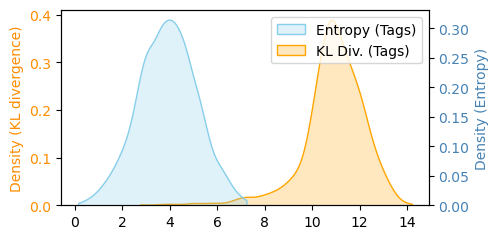

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

min_entropy = res["entropy"].min()
max_entropy = res["entropy"].max()

min_kldiv = res["KL_div"].min()
max_kldiv = res["KL_div"].max()

# Initialize the plot
fig, ax2 = plt.subplots(figsize=(5, 2.5))

sns.kdeplot(res["KL_div"], ax=ax2, label="KL Div. (Tags)", fill=True, color="orange", linestyle="-", clip=(min_kldiv, max_kldiv))

ax2.set_ylabel("Density (KL divergence)", color="#FF8C00")
ax2.tick_params(axis="y", labelcolor="#FF8C00")

# Create a second y-axis for KL_div
ax1 = ax2.twinx()


# Plot the KDE for entropy on the first y-axis
sns.kdeplot(res["entropy"], ax=ax1, label="Entropy (Tags)", fill=True, color="skyblue", linestyle="-", clip=(min_entropy, max_entropy))

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Entropy)", color="#4682B4")
ax1.tick_params(axis="y", labelcolor="#4682B4")


# Add a title and legend
# plt.title("KDE of Entropy and KL Divergence with Dual Axes")
handles, labels = ax1.get_legend_handles_labels()  # Get handles and labels from ax1
handles2, labels2 = ax2.get_legend_handles_labels()  # Get handles and labels from ax2

# Combine the handles and labels from both axes
handles.extend(handles2)
labels.extend(labels2)

# Show the legend
plt.legend(handles=handles, labels=labels, loc="upper right")
fig.tight_layout()

# ax1.set_xlim(-0.5, 24)
plt.savefig("rq2_tag_neuron_tfidf.pdf")

In [32]:
res.sort_values("entropy")

,id,tag,entropy,KL_div,norm_entropy_diff
1681,1687,cz,0.138681,12.708554,0.982139
1413,1419,Rhythmic Noise,0.250693,11.014520,0.967714
1306,1310,heard on last-fm 08,0.324285,13.562663,0.958236
1418,1424,hungarian,0.507342,12.576320,0.934660
1734,1740,coldwave,0.507868,11.117542,0.934593
...,...,...,...,...,...
134,134,00s,7.064835,4.361177,0.090133
52,52,alternative,7.093626,3.627802,0.086425
88,88,Awesome,7.108158,3.883317,0.084554
51,51,rock,7.220105,2.852386,0.070136


In [33]:
res.sort_values("KL_div")

,id,tag,entropy,KL_div,norm_entropy_diff
54,54,favorites,7.231406,2.746149,0.068681
51,51,rock,7.220105,2.852386,0.070136
115,115,Love,7.036248,3.389416,0.093815
52,52,alternative,7.093626,3.627802,0.086425
88,88,Awesome,7.108158,3.883317,0.084554
...,...,...,...,...,...
1280,1284,worship,3.544920,13.641658,0.543456
748,751,hardstyle,0.671539,13.889047,0.913514
66,66,bluegrass,3.557359,13.917869,0.541855
1672,1678,Rock Argentino,3.593773,14.098574,0.537165
